# Results analysis 

Here will be checked if the gathered vecctors are detectable in an easy way through other methods then MLP: 
- Comparing them with the original steering vector.
    - Cosine similarity
    - Classification of the steering vector with the trained classifier
    - Checking where in the sentence this vecotr is the more visible
- Visualisation of PCA, t-SNE
- Training SVM

In [1]:
# gloabl imports
import yaml
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from matplotlib.ticker import ScalarFormatter



# Local imports
sys.path.append('../src')
from detection import *
from ml_model import *
import utils


/home/thibaua25/Documents/Prog/LLMs/watermarking/mistral_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:


root_folder = "../data/metro_news_v3.254/Meta-Llama-3-8B/gen_512_temp0.5/steering_noisesparse_0.003_4_layers15/[15]/"
root_folder = "../data/guardian_from_nov2025_articles_v2.10k/Llama-3.1-8B/gen_512_temp0.7/steering_noisesparse_0.003_5_layers15/[15]/"
root_folder = "../data/Hello-SimpleAI/HC3/Meta-Llama-3-8B-Instruct/gen_512_temp0.7/steering_noisesparse_0.003_5_layers15/[15]/"



param_type = "detection"
detection_hash_code = "1b0d3c5c"#"c317016e" #"ad0b8f0e" #"480ad149" #"e79a486e"

data_type = "activation_gathering"
steered_hash_code1 = "fb816072" #"52aa07b8" #"d85af416" #"296d1131" #"ab0130d3"
steered_hash_code2 = "71f76e65" #"194d020d" #"52d05efe" #"3f1bee9d" #"fa5a25ff"

# Import the parameters
with open(root_folder + param_type + "_params_" + detection_hash_code + ".json", "r") as f:
    params = yaml.safe_load(f)

# Load the detection results
detection_dict = pd.read_pickle(root_folder + param_type + "_" + detection_hash_code + ".pkl")

# Load the input data
steered_data1 = pd.read_pickle(root_folder + data_type + "_" + steered_hash_code1 + ".pkl")
steered_data2 = pd.read_pickle(root_folder + data_type + "_" + steered_hash_code2 + ".pkl")

In [6]:
plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



### Data exploration

In [7]:
# Print out some info about the data
print("Steeed data 1 shape:", steered_data1.shape)
print("Steeed data 2 shape:", steered_data2.shape)
print("Detection dict keys:", detection_dict.keys())

print("List of columns in steered_data1:", steered_data1.columns)
print("Sample of steered_data1:")
print(steered_data1.head())

Steeed data 1 shape: (10, 21)
Steeed data 2 shape: (10, 21)
Detection dict keys: dict_keys(['train_loss', 'train_accuracy', 'validation_accuracy', 'validation_loss', 'test_accuracy', 'test_ground_truth', 'test_sentence_ids', 'test_predictions', 'test_probabilities', 'test_token_ids', 'split_list', 'model'])
List of columns in steered_data1: Index(['classification_label', 'input_text', 'input_text_id',
       'input_token_length', 'input_token_ids', 'output_text',
       'output_token_ids', 'output_token_strings', 'steering_noise',
       'steering_type', 'steering_layers', 'key_vector', 'params',
       'split_label', 'original_text', 'paraphrased_text', 'perplexity',
       'log_diversity', 'quality', 'activations', 'paraphrased_activations'],
      dtype='object')
Sample of steered_data1:
   classification_label                                         input_text  \
0                    51  Why is every book I hear about a " NY Times # ...   
1                    51  If salt is so bad

### Visualisation of the activations

In [9]:
sentence_ids = [0]

for sentence_id in sentence_ids:

    print("Inpupt: ", steered_data1["input_text"].iloc[sentence_id])

    print("> original text", steered_data1["original_text"].iloc[sentence_id])
    # print("> original text", steered_data2["original_text"].iloc[sentence_id])

    # print("> Paraph text", steered_data1["paraphrased_text"].iloc[sentence_id])
    # print("> Paraph text", steered_data2["paraphrased_text"].iloc[sentence_id])
# steered_data2["paraphrased_activations"]

Inpupt:  Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n't there only be one " # 1 " best seller ? Please explain like I'm five.
> original text When books are published, they're compared to other books that people have read and liked. This helps readers know which books are popular. The New York Time's list shows how many times readers and readers' fingers (that means the same thing) got their fingers on each book.

The words "Best" and "Fingered" mean the same thing: both refer to a person’s hands being involved when something was picked up. In this case, fingers were used at the time of the other time when someone else’s fingers were picked).

Books are compared for a while before the results are counted. When the numbers are counted again, more and not fewer times, another book was collected.


In [127]:
subset_of_sentences_size = 950 #254

def extract_activations(x):
    # Extract activations from steered data
    list_of_activations = np.array(x[list(x.keys())[0]])
    return list_of_activations

activations1 = steered_data1["activations"].apply(extract_activations).values[:subset_of_sentences_size]
activations2 = steered_data2["activations"].apply(extract_activations).values[:subset_of_sentences_size]

activations1_paraphrased = steered_data1["paraphrased_activations"].apply(extract_activations).values[:subset_of_sentences_size]
activations2_paraphrased = steered_data2["paraphrased_activations"].apply(extract_activations).values[:subset_of_sentences_size]

print("Nb sentences. 1st group:", activations1.shape, "2nd group:", activations2.shape)
print("Type of data for each sentence:", activations1[0].shape)


Nb sentences. 1st group: (950,) 2nd group: (950,)
Type of data for each sentence: (394, 4096)


In [128]:
# Print out all the sentences accorging to their labels on a 2d PCA plot
X = np.concatenate([np.vstack(activations1), np.vstack(activations2)], axis=0)
y = []
for a in activations1:
    y += [0]*len(a)
for a in activations2:
    y += [1]*len(a)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
# Standardize the data
X_std = StandardScaler().fit_transform(X)
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

KeyboardInterrupt: 

In [43]:
# Train a t_SNE model
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_std)

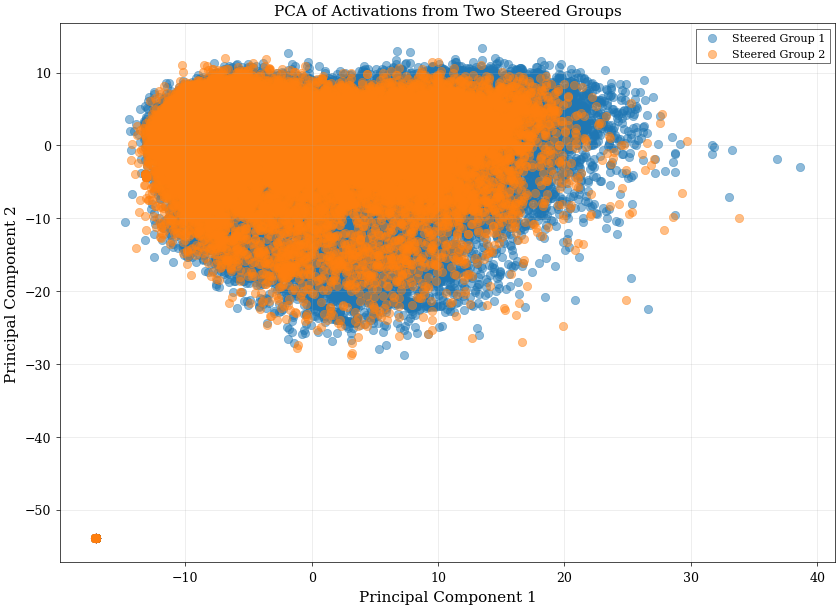

In [44]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], label='Steered Group 1', alpha=0.5)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], label='Steered Group 2', alpha=0.5)
plt.title('PCA of Activations from Two Steered Groups')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

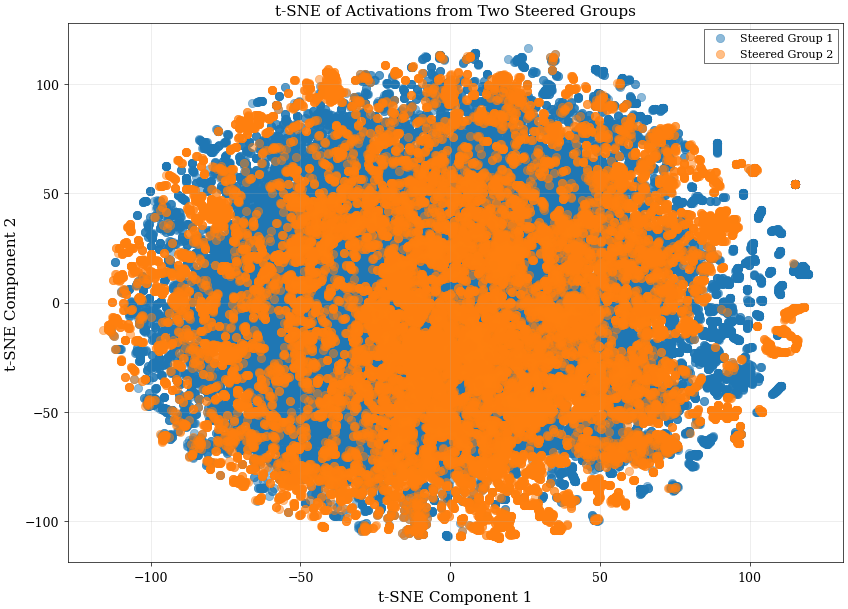

In [45]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], label='Steered Group 1', alpha=0.5)
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], label='Steered Group 2', alpha=0.5)
plt.title('t-SNE of Activations from Two Steered Groups')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid()
plt.show()

It seems like with low complexity discriminators, the difference between the elemnts is not that easy to find. Particularly it seems like some datapoints are outliers by far. This is the case:
- With smaller subset of sentences
- With paraphrased or original text

## Check matching to the random steering vector

Shape of steeve1: (4096,)
(4096,)


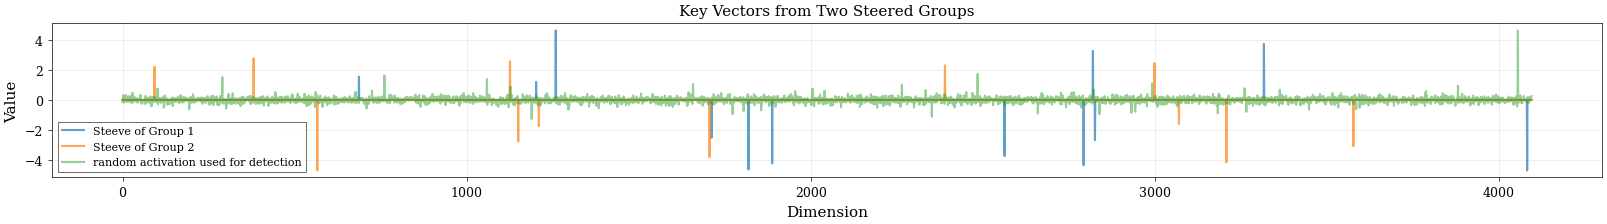

In [129]:
steeve1 = steered_data1["key_vector"][0]    # Extract the first key vector (they are all the same)
steeve2 = steered_data2["key_vector"][0]

print("Shape of steeve1:", steeve1.shape)
print(activations1[0][0].shape)

plt.figure(figsize=(20, 2))
plt.plot(steeve1, label='Steeve of Group 1', alpha=0.7)
plt.plot(steeve2, label='Steeve of Group 2', alpha=0.7)
plt.plot(activations2[1][100], label='random activation used for detection', alpha=0.5)
plt.title('Key Vectors from Two Steered Groups')
plt.xlabel('Dimension')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

In [130]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

similarity_dict = {
    "steeve1_act1": [],
    "steeve1_act1_paraphrased": [],
    "steeve1_act2": [],
    "steeve1_act2_paraphrased": [],
    "steeve2_act1": [],
    "steeve2_act1_paraphrased": [],
    "steeve2_act2": [],
    "steeve2_act2_paraphrased": []
}
for i in range(len(activations1)):

    similarity_dict["steeve1_act1"] += [cosine_similarity(steeve1, ac) for ac in activations1[i]]
    similarity_dict["steeve1_act1_paraphrased"] += [cosine_similarity(steeve1, ac) for ac in activations1_paraphrased[i]]
    similarity_dict["steeve1_act2"] += [cosine_similarity(steeve1, ac) for ac in activations2[i]]
    similarity_dict["steeve1_act2_paraphrased"] += [cosine_similarity(steeve1, ac) for ac in activations2_paraphrased[i]]
    similarity_dict["steeve2_act1"] += [cosine_similarity(steeve2, ac) for ac in activations1[i]]
    similarity_dict["steeve2_act1_paraphrased"] += [cosine_similarity(steeve2, ac) for ac in activations1_paraphrased[i]]
    similarity_dict["steeve2_act2"] += [cosine_similarity(steeve2, ac) for ac in activations2[i]]
    similarity_dict["steeve2_act2_paraphrased"] += [cosine_similarity(steeve2, ac) for ac in activations2_paraphrased[i]]


Average cosine similarities:
steeve1_act1: -0.0005291134002618492
steeve1_act1_paraphrased: -0.001048932084813714
steeve1_act2: -0.00383780337870121
steeve1_act2_paraphrased: -0.0027886019088327885
steeve2_act1: -0.0005845322157256305
steeve2_act1_paraphrased: -0.0015277423663064837
steeve2_act2: 0.004048781935125589
steeve2_act2_paraphrased: 0.002548081334680319


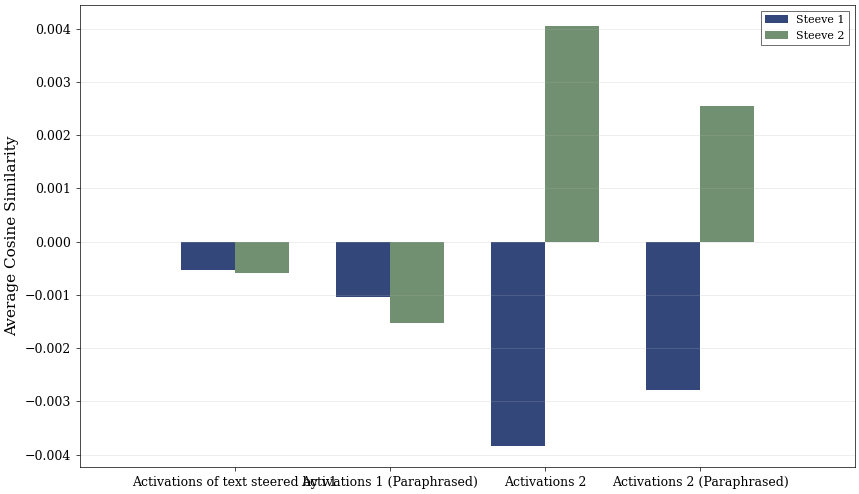

In [131]:
import itertools

# prepare grouped averages and plot grouped bar chart by category (steeve1 vs steeve2)
keys = list(similarity_dict.keys())
avg_similarities = [np.mean(similarity_dict[k]) for k in keys]

categories = ['Activations of text steered by v1', 'Activations 1 (Paraphrased)', 'Activations 2', 'Activations 2 (Paraphrased)']
steeve1_vals = avg_similarities[0:4]
steeve2_vals = avg_similarities[4:8]

colors_palette = [utils.batlow_categorical_colors[i] for i in [0 , 5,  4, 6]]


x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, steeve1_vals, width, label='Steeve 1', color=colors_palette[0], alpha=0.8)
ax.bar(x + width/2, steeve2_vals, width, label='Steeve 2', color=colors_palette[1], alpha=0.8)

# monkeypatch plt.bar to cycle provided colors if their length doesn't match data length
_orig_bar = plt.bar
def _bar_wrapper(*args, **kwargs):
    if 'color' in kwargs and isinstance(kwargs['color'], (list, tuple)):
        try:
            n = len(args[0])
        except Exception:
            n = None
        colors = list(kwargs['color'])
        if n is not None and len(colors) != n and len(colors) > 0:
            kwargs['color'] = [c for c in itertools.islice(itertools.cycle(colors), n)]
    return _orig_bar(*args, **kwargs)
plt.bar = _bar_wrapper
print("Average cosine similarities:")
for key in similarity_dict.keys():
    print(f"{key}: {np.mean(similarity_dict[key])}")

# Add secondary x-axis labels for the pairs
# Calculate the center position of each pair

# # After setting up the main x-axis labels
# ax.set_xticks(x - width/2 + (4 - 1) * width / 2)
# ax.set_xticklabels(categories)

# pair1_center = x - width/2
# pair2_center = x + width/2

# # Add text labels below the main axis
# ax.text(pair1_center + 0.5, -0.13, 'Our Method', 
#         ha='center', va='top',
#         transform=ax.get_xaxis_transform())

# ax.text(pair2_center + 0.5, -0.13, 'KGW Watermarking', 
#         ha='center', va='top',
#         transform=ax.get_xaxis_transform())
# # Bracket for first pair
# bracket1_x = x[0] - width/2 - 0.5
# bracket1_width = x[1] - x[0] + width + 1.0
# ax.plot([bracket1_x, bracket1_x + bracket1_width], [-0.1, -0.1], 
#         color='black', linewidth=1, transform=ax.get_xaxis_transform(), clip_on=False)

# # Bracket for second pair
# bracket2_x = x[2] - width/2 - 0.5
# bracket2_width = x[3] - x[2] + width + 1.0
# ax.plot([bracket2_x, bracket2_x + bracket2_width], [-0.1, -0.1], 
#         color='black', linewidth=1, transform=ax.get_xaxis_transform(), clip_on=False)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Average Cosine Similarity')
# ax.set_title('Average Cosine Similarity grouped by activation type and steeve')
ax.legend()
ax.grid(axis='y')

ax.set_xlim(-1, 4)




plt.savefig("similarity_bar_chart.png")

plt.show()


### Check the similarity according to the place in the sentence.

In [132]:
# Keep only sentences with length larger then 150
min_sentence_length = 250
activations1 = [act for act in activations1 if len(act) > min_sentence_length]
activations2 = [act for act in activations2 if len(act) > min_sentence_length]
activations1_paraphrased = [act for act in activations1_paraphrased if len(act) > min_sentence_length]
activations2_paraphrased = [act for act in activations2_paraphrased if len(act) > min_sentence_length]

min_sentence_length = min([len(activations1[i]) for i in range(len(activations1))] + [len(activations2[i]) for i in range(len(activations2))] + 
                          [len(activations1_paraphrased[i]) for i in range(len(activations1_paraphrased))] + [len(activations2_paraphrased[i]) for i in range(len(activations2_paraphrased))])
print("Minimum sentence length across all groups:", min_sentence_length)

similarity_dict = {
    "steeve1_act1": np.zeros(min_sentence_length),
    "steeve1_act2": np.zeros(min_sentence_length),
    "steeve1_act1_paraphrased": np.zeros(min_sentence_length),
    "steeve1_act2_paraphrased": np.zeros(min_sentence_length),
    "steeve2_act1": np.zeros(min_sentence_length),
    "steeve2_act2": np.zeros(min_sentence_length),
    "steeve2_act1_paraphrased": np.zeros(min_sentence_length),
    "steeve2_act2_paraphrased": np.zeros(min_sentence_length)
}

print("All number of sequences:", len(activations1), len(activations2), len(activations1_paraphrased), len(activations2_paraphrased))
min_num_seq = min(len(activations1), len(activations2), len(activations1_paraphrased), len(activations2_paraphrased))

for i in range(len(activations1)):
    # Fill the similarity dicts for each token position up to min_sentence_length
    similarity_dict["steeve1_act1"] += np.array([cosine_similarity(steeve1, ac) for ac in activations1[i][:min_sentence_length]])
    similarity_dict["steeve2_act1"] += np.array([cosine_similarity(steeve2, ac) for ac in activations1[i][:min_sentence_length]])
for i in range(len(activations1_paraphrased)):
    similarity_dict["steeve1_act1_paraphrased"] += np.array([cosine_similarity(steeve1, ac) for ac in activations1_paraphrased[i][:min_sentence_length]])
    similarity_dict["steeve2_act1_paraphrased"] += np.array([cosine_similarity(steeve2, ac) for ac in activations1_paraphrased[i][:min_sentence_length]])
for i in range(len(activations2)):
    similarity_dict["steeve1_act2"] += np.array([cosine_similarity(steeve1, ac) for ac in activations2[i][:min_sentence_length]])
    similarity_dict["steeve2_act2"] += np.array([cosine_similarity(steeve2, ac) for ac in activations2[i][:min_sentence_length]])
for i in range(len(activations2_paraphrased)):
    similarity_dict["steeve2_act2_paraphrased"] += np.array([cosine_similarity(steeve2, ac) for ac in activations2_paraphrased[i][:min_sentence_length]])
    similarity_dict["steeve1_act2_paraphrased"] += np.array([cosine_similarity(steeve1, ac) for ac in activations2_paraphrased[i][:min_sentence_length]])

Minimum sentence length across all groups: 251
All number of sequences: 833 745 241 226


In [133]:
name_bij_dict = {
    "steeve1_act1": "$\langle v_1, A_l(t_1) \\rangle_{\cos}$",
    "steeve1_act1_paraphrased": "$\langle v_1, A_l(t_1) \\rangle_{\cos}$ (Paraphrased)",
    "steeve1_act2": "$\langle v_1, A_l(t_2) \\rangle_{\cos}$",
    "steeve1_act2_paraphrased": "$\langle v_1, A_l(t_2) \\rangle_{\cos}$ (Paraphrased)",
    "steeve2_act1": "$\langle v_2, A_l(t_1) \\rangle_{\cos}$",
    "steeve2_act1_paraphrased": "$\langle v_2, A_l(t_1) \\rangle_{\cos}$ (Paraphrased)",
    "steeve2_act2": "$\langle v_2, A_l(t_2) \\rangle_{\cos}$",
    "steeve2_act2_paraphrased": "$\langle v_2, A_l(t_2) \\rangle_{\cos}$ (Paraphrased)"
}

In [134]:
# # plot for each key a small sub-plot of average cosine similarity per token position
# # Fill the surface between the plot and y=0 with a light color depending on the key (paraphrased vs non-paraphrased)
# fig, axs = plt.subplots(4, 2, figsize=(20, 10))
# for key in similarity_dict.keys():
#     color = 'tab:blue' if 'steeve1' in key else 'tab:orange'
#     background_color = 'lightblue' if 'paraphrased' in key else 'lightgreen'
#     ax = axs.flatten()[list(similarity_dict.keys()).index(key)]
#     avg_sim = similarity_dict[key] / len(activations1)  # Average over number of sentences
#     ax.plot(range(min_sentence_length), avg_sim, label=key, color=color, linewidth=2)

#     ax.fill_between(range(min_sentence_length), avg_sim, 0, where=(avg_sim >= 0), facecolor=background_color, alpha=0.5)
#     ax.fill_between(range(min_sentence_length), avg_sim, 0, where=(avg_sim < 0), facecolor='lightcoral', alpha=0.5)
    
#     # Set a dotted line at y=0
#     ax.axhline(0, color='red', linestyle='--', linewidth=1)

#     ax.set_title(f'{ name_bij_dict[key] }')
#     ax.set_xlabel('Token Position')
#     ax.set_ylabel('Average Cosine Similarity')
#     ax.legend()
#     ax.grid()
#     # ax.set_facecolor(background_color)

# plt.tight_layout()
# plt.savefig("similarity_per_token_position.png")
# plt.savefig("similarity_per_token_position.pdf")
# plt.show()

In [135]:
color_palette = utils.batlow_categorical_colors
# print("Color palette used:", color_palette)
thi = ['#011959', '#FACCFA', '#828231', '#226061', '#F29D6D', '#4D734D', '#114360', '#C09036', '#FDB4B4', '#DD954D', '#356A59', '#FCBFD6', '#175262', '#677B3E']
#

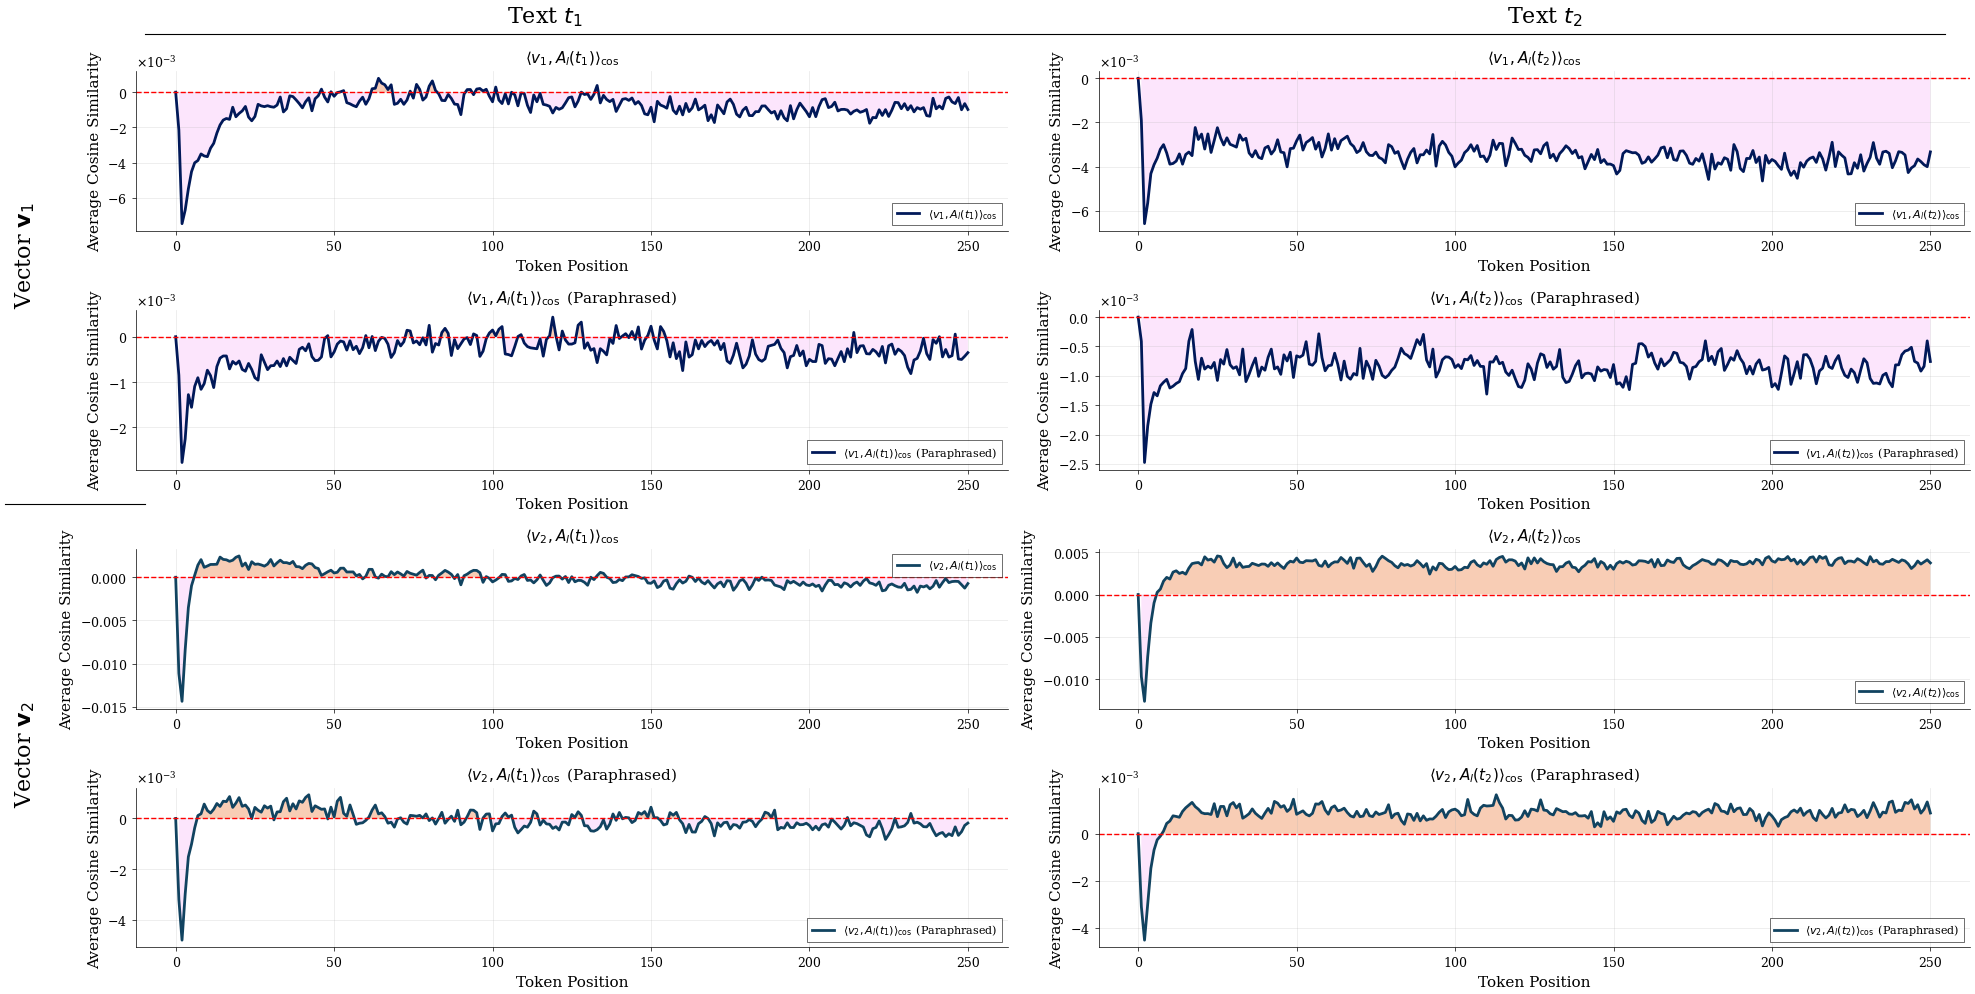

In [136]:
from matplotlib.lines import Line2D
fig, axs = plt.subplots(4, 2, figsize=(20, 10))


formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 4)) 

for key in similarity_dict.keys():
    color = color_palette[0] if "steeve1" in key else color_palette[6] 
    # 'tab:blue' if 'steeve1' in key else 'tab:orange'
    background_color = color_palette[4] if 'paraphrased' in key else color_palette[4]
    # 'lightblue' if 'paraphrased' in key else 'lightgreen'
    ax = axs.flatten()[list(similarity_dict.keys()).index(key)]
    avg_sim = similarity_dict[key] / len(activations1)  # Average over number of sentences
    ax.plot(range(min_sentence_length), avg_sim, label=name_bij_dict[key], color=color, linewidth=2)

    ax.fill_between(range(min_sentence_length), avg_sim, 0, where=(avg_sim >= 0), facecolor=background_color, alpha=0.5)
    ax.fill_between(range(min_sentence_length), avg_sim, 0, where=(avg_sim < 0), facecolor=color_palette[1], alpha=0.5)
    
    # Set a dotted line at y=0
    ax.axhline(0, color="red", linestyle='--', linewidth=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(f'{name_bij_dict[key]}')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Average Cosine Similarity')
    ax.legend()
    ax.grid()
    
    ax.yaxis.set_major_formatter(formatter)

# Add column labels at the top
fig.text(0.28, 1.0, 'Text $t_1$', ha='center', va='top', fontsize=16)
fig.text(0.78, 1.0, 'Text $t_2$', ha='center', va='top', fontsize=16)

# Add row labels on the left (rotated 90°)
fig.text(0.02, 0.75, 'Vector $\mathbf{v}_1$', ha='center', va='center', fontsize=16, rotation=90)
fig.text(0.02, 0.25, 'Vector $\mathbf{v}_2$', ha='center', va='center', fontsize=16, rotation=90)


# Add horizontal line separating column labels from subplots
line_h = Line2D([0.08, 0.98], [0.97, 0.97], transform=fig.transFigure, color='black', linewidth=0.8)
fig.add_artist(line_h)

# # Add vertical line separating column labels
# line_v_col = Line2D([0.55, 0.55], [0.97, 1.0], transform=fig.transFigure, color='black', linewidth=1)
# fig.add_artist(line_v_col)

# Add horizontal line separating row labels (between Label A and Label B)
line_h_row = Line2D([0.01, 0.08], [0.5, 0.5], transform=fig.transFigure, color='black', linewidth=0.8)
fig.add_artist(line_h_row)


plt.tight_layout(rect=[0.03, 0, 1, 0.97])  # Adjust to make room for labels
plt.savefig("similarity_per_token_position.png")
plt.savefig("similarity_per_token_position.pdf")
plt.show()

### Use cosine similarity to classify the texts

In [137]:
def similarity_classification(token):
    c1 = cosine_similarity(token, steeve1)
    c2 = cosine_similarity(token, steeve2)
    if c1 > c2:
        return 0
    else:
        return 1 
    
def compute_classification_accuracy(activations, true_label):
    correct = 0
    total = 0
    for sentence_activations in activations:
        for token_activation in sentence_activations:
            pred_label = similarity_classification(token_activation)
            if pred_label == true_label:
                correct += 1
            total += 1
    return correct / total

acc1 = compute_classification_accuracy(activations1, 0)
acc2 = compute_classification_accuracy(activations2, 1)
print(f"Classification accuracy for steered group 1: {acc1*100:.2f}%")
print(f"Classification accuracy for steered group 2: {acc2*100:.2f}%")

overall_acc = (acc1 + acc2) / 2
print(f"Overall classification accuracy: {overall_acc*100:.2f}%")

acc1_paraphrased = compute_classification_accuracy(activations1_paraphrased, 0)
acc2_paraphrased = compute_classification_accuracy(activations2_paraphrased, 1)
print(f"Classification accuracy for steered group 1 (paraphrased): {acc1_paraphrased*100:.2f}%")
print(f"Classification accuracy for steered group 2 (paraphrased): {acc2_paraphrased*100:.2f}%")
overall_acc_paraphrased = (acc1_paraphrased + acc2_paraphrased) / 2
print(f"Overall classification accuracy (paraphrased): {overall_acc_paraphrased*100:.2f}%")

Classification accuracy for steered group 1: 50.10%
Classification accuracy for steered group 2: 68.44%
Overall classification accuracy: 59.27%
Classification accuracy for steered group 1 (paraphrased): 49.62%
Classification accuracy for steered group 2 (paraphrased): 64.77%
Overall classification accuracy (paraphrased): 57.19%


### Sentence-level voting

In [138]:
def compute_classification_at_sentence_level(activations, true_label):
    correct = 0
    total = 0
    for sentence_activations in activations:
        votes = {0: 0, 1: 0}
        for token_activation in sentence_activations:
            pred_label = similarity_classification(token_activation)
            votes[pred_label] += 1

        # Majority vote
        pred_sentence_label = 0 if votes[0] > votes[1] else 1
        if pred_sentence_label == true_label:
            correct += 1
        total += 1
    return correct / total

acc1_sentence = compute_classification_at_sentence_level(activations1, 0)
acc2_sentence = compute_classification_at_sentence_level(activations2, 1)
print(f"Sentence-level classification accuracy for steered group 1: {acc1_sentence*100:.2f}%")
print(f"Sentence-level classification accuracy for steered group 2: {acc2_sentence*100:.2f}%")
overall_acc_sentence = (acc1_sentence + acc2_sentence) / 2
print(f"Overall sentence-level classification accuracy: {overall_acc_sentence*100:.2f}%")

acc1_sentence_paraphrased = compute_classification_at_sentence_level(activations1_paraphrased, 0)
acc2_sentence_paraphrased = compute_classification_at_sentence_level(activations2_paraphrased, 1)
print(f"Sentence-level classification accuracy for steered group 1 (paraphrased): {acc1_sentence_paraphrased*100:.2f}%")
print(f"Sentence-level classification accuracy for steered group 2 (paraphrased): {acc2_sentence_paraphrased*100:.2f}%")
overall_acc_sentence_paraphrased = (acc1_sentence_paraphrased + acc2_sentence_paraphrased) / 2
print(f"Overall sentence-level classification accuracy (paraphrased): {overall_acc_sentence_paraphrased*100:.2f}%")

Sentence-level classification accuracy for steered group 1: 49.82%
Sentence-level classification accuracy for steered group 2: 96.11%
Overall sentence-level classification accuracy: 72.96%
Sentence-level classification accuracy for steered group 1 (paraphrased): 46.47%
Sentence-level classification accuracy for steered group 2 (paraphrased): 95.13%
Overall sentence-level classification accuracy (paraphrased): 70.80%


### Sentence-level classification with weighted similarity

In [139]:
def compute_classification_at_sentence_level_weighted(activations, true_label):
    correct = 0
    total = 0
    for sentence_activations in activations:
        votes = {0: 0, 1: 0}
        for token_activation in sentence_activations:
            c1 = cosine_similarity(token_activation, steeve1)
            c2 = cosine_similarity(token_activation, steeve2)
            votes[0] += c1
            votes[1] += c2
        # Final prediction is the one with most votes
        final_pred = 0 if votes[0] > votes[1] else 1
        if final_pred == true_label:
            correct += 1
        total += 1
    return correct / total

acc1_sentence_w = compute_classification_at_sentence_level_weighted(activations1, 0)
acc2_sentence_w = compute_classification_at_sentence_level_weighted(activations2, 1)
print(f"Weighted sentence-level classification accuracy for steered group 1: {acc1_sentence_w*100:.2f}%")
print(f"Weighted sentence-level classification accuracy for steered group 2: {acc2_sentence_w*100:.2f}%")
overall_acc_sentence_w = (acc1_sentence_w + acc2_sentence_w) / 2
print(f"Overall weighted sentence-level classification accuracy: {overall_acc_sentence_w*100:.2f}%")

acc1_sentence_w_paraphrased = compute_classification_at_sentence_level_weighted(activations1_paraphrased, 0)
acc2_sentence_w_paraphrased = compute_classification_at_sentence_level_weighted(activations2_paraphrased, 1)
print(f"Weighted sentence-level classification accuracy for steered group 1 (paraphrased): {acc1_sentence_w_paraphrased*100:.2f}%")
print(f"Weighted sentence-level classification accuracy for steered group 2 (paraphrased): {acc2_sentence_w_paraphrased*100:.2f}%")
overall_acc_sentence_w_paraphrased = (acc1_sentence_w_paraphrased + acc2_sentence_w_paraphrased) / 2
print(f"Overall weighted sentence-level classification accuracy (paraphrased): {overall_acc_sentence_w_paraphrased*100:.2f}%")

Weighted sentence-level classification accuracy for steered group 1: 51.02%
Weighted sentence-level classification accuracy for steered group 2: 96.11%
Overall weighted sentence-level classification accuracy: 73.56%
Weighted sentence-level classification accuracy for steered group 1 (paraphrased): 46.89%
Weighted sentence-level classification accuracy for steered group 2 (paraphrased): 95.13%
Overall weighted sentence-level classification accuracy (paraphrased): 71.01%
